**This Notebook will be for explore and explain CBC Dataset that lead us to better understanding to our data and better modeling experience.**

#Explination

**Data Columns**
  - **Gender**: 0-> Male 1-> Female

  - **Age**
  - **HB** -> Hemoglobin
  - **RBC** -> Red Blood Cells Count
  - **WBC** -> White Blood Cells Count
  - **PLATELETS** -> small, colorless, disc-shaped cell fragments in the blood that are essential for blood clotting and wound healing.
  - **LYMP** -> lymphocytes are a type of white blood cell that play a central role in the immune system by identifying and destroying foreign invaders like bacteria, viruses, and cancer cells.
  - **MONO** -> Monocytes are the largest type of white blood cell in a CBC, acting as "scavengers" that migrate to tissues to ingest pathogens and help repair damaged cells.
  - **HCT** -> Hematocrit which is the measurement of the percentage of your total blood volume that is made up of red blood cells.

  - **MCV** -> Mean Corpuscular Volume, which measures the average size and volume of your red blood cells to help diagnose different types of anemia.

  - **MCH** -> Mean Corpuscular Hemoglobin, which is the average amount of hemoglobin found in a single red blood cell, which helps determine how well your blood carries oxygen.

  - **MCHC** -> Mean Corpuscular Hemoglobin Concentration,which is a measurement of the average concentration of hemoglobin inside a single red blood cell relative to its size.

  - **RDW** -> Red Cell Distribution Width,which Measures the variation in size of your red blood cells; a high RDW means your red cells are significantly different sizes (often seen in various types of anemia).

  - **PDW** -> Platelet Distribution Width,which Measures how much your platelets vary in size, which helps determine if the bone marrow is producing them normally.

  - **MPV** -> Mean Platelet Volume,which Calculates the average size of your platelets; larger platelets are usually younger and more active, often indicating the body is rushing to replace lost ones.

  - **PCT** -> Plateletcrit,which Represents the total volume percentage of your blood occupied by platelets (similar to how Hematocrit works for red blood cells).

  - **Diagnose** -> The Final Diagnose

# Libraries

In [307]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, hamming_loss, f1_score, classification_report
from sklearn.preprocessing import MultiLabelBinarizer

# Data Preprocessing

In [308]:
df=pd.read_csv("/content/drive/MyDrive/Graduation/ml project/cbc_Dataset.csv")

In [309]:
df.to_csv("original_cbc.csv")

In [310]:
df.head()

,Gender,Age,Hb,RBC,WBC,PLATELETS,LYMP,MONO,HCT,MCV,MCH,MCHC,RDW,PDW,MPV,PCT,Diagnosis
0,0,45,12.1,4.25,12300,404000.0,29.0,4.6,36.2,85.2,28.4,33.4,14.0,13.6,10.2,0.410,Anemia of Chronic Disease
1,0,58,12.3,4.34,12000,392000.0,30.0,5.1,37.1,85.5,28.3,33.1,14.0,13.8,10.2,0.390,Anemia of Chronic Disease
2,0,49,12.6,4.35,11300,387000.0,23.5,7.0,38.2,87.9,28.9,32.9,14.1,14.9,10.7,0.410,Anemia of Chronic Disease
3,0,43,12.0,4.30,5000,298000.0,43.1,6.5,35.8,83.4,27.9,33.5,13.7,15.3,8.5,0.254,Anemia of Chronic Disease
4,0,29,11.4,4.36,8720,267000.0,31.1,5.9,35.1,80.4,26.1,32.5,14.0,15.6,8.3,0.222,Anemia of Chronic Disease


In [311]:
df.tail()

,Gender,Age,Hb,RBC,WBC,PLATELETS,LYMP,MONO,HCT,MCV,MCH,MCHC,RDW,PDW,MPV,PCT,Diagnosis
7191,1,32,20.1,4.83,9900,443000.0,79.14,5.4,39.3,81.5,24.3,29.9,15.9,15.3,7.6,0.337,Viral Infections
7192,0,42,13.3,5.77,6180,206000.0,51.10,2.6,45.9,79.6,23.1,29.0,14.9,16.4,9.8,0.202,Viral Infections
7193,0,45,15.0,6.19,10180,190000.0,61.30,6.2,48.9,78.9,24.3,30.7,14.8,15.8,7.9,0.150,Viral Infections
7194,1,56,12.9,5.30,5900,304000.0,67.80,7.6,43.1,81.2,24.3,30.0,14.5,15.4,7.3,0.222,Viral Infections
7195,1,24,13.0,4.32,4340,291000.0,66.00,8.0,38.7,89.6,30.0,33.5,13.9,15.7,8.9,2.600,Viral Infections


In [312]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7196 entries, 0 to 7195
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Gender     7196 non-null   int64  
 1   Age        7196 non-null   int64  
 2   Hb         7196 non-null   float64
 3   RBC        7196 non-null   float64
 4   WBC        7196 non-null   int64  
 5   PLATELETS  7196 non-null   float64
 6   LYMP       7196 non-null   float64
 7   MONO       7196 non-null   float64
 8   HCT        7196 non-null   float64
 9   MCV        7196 non-null   float64
 10  MCH        7196 non-null   float64
 11  MCHC       7196 non-null   float64
 12  RDW        7196 non-null   float64
 13  PDW        7196 non-null   float64
 14  MPV        7196 non-null   float64
 15  PCT        7196 non-null   float64
 16  Diagnosis  7196 non-null   object 
dtypes: float64(13), int64(3), object(1)
memory usage: 955.8+ KB


In [313]:
df.index

RangeIndex(start=0, stop=7196, step=1)

In [314]:
df.columns

Index(['Gender', 'Age', 'Hb', 'RBC', 'WBC', 'PLATELETS', 'LYMP', 'MONO', 'HCT',
       'MCV', 'MCH', 'MCHC', 'RDW', 'PDW', 'MPV', 'PCT', 'Diagnosis'],
      dtype='object')

In [315]:
df.columns=df.columns.str.lower()
df.columns

Index(['gender', 'age', 'hb', 'rbc', 'wbc', 'platelets', 'lymp', 'mono', 'hct',
       'mcv', 'mch', 'mchc', 'rdw', 'pdw', 'mpv', 'pct', 'diagnosis'],
      dtype='object')

## Gender Column

In [316]:
original_df=df.copy()

In [317]:
df['gender'].value_counts()

,count
gender,
1,3770
0,3426


- There are difference in normal ranges for diagnoses between males and femals and our focus with females beacuse our project target pragnancies so deleting male data will give us more Credibility and Transparency to our project

In [318]:
df=df[df['gender']!=0].reset_index(drop=True)

In [319]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3770 entries, 0 to 3769
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   gender     3770 non-null   int64  
 1   age        3770 non-null   int64  
 2   hb         3770 non-null   float64
 3   rbc        3770 non-null   float64
 4   wbc        3770 non-null   int64  
 5   platelets  3770 non-null   float64
 6   lymp       3770 non-null   float64
 7   mono       3770 non-null   float64
 8   hct        3770 non-null   float64
 9   mcv        3770 non-null   float64
 10  mch        3770 non-null   float64
 11  mchc       3770 non-null   float64
 12  rdw        3770 non-null   float64
 13  pdw        3770 non-null   float64
 14  mpv        3770 non-null   float64
 15  pct        3770 non-null   float64
 16  diagnosis  3770 non-null   object 
dtypes: float64(13), int64(3), object(1)
memory usage: 500.8+ KB


In [320]:
df['gender'].value_counts()

,count
gender,
1,3770


In [321]:
df.index

RangeIndex(start=0, stop=3770, step=1)

- Drop Gender Column because it doesnot cause any difference know

In [322]:
df.drop(columns=['gender'],inplace=True)

In [323]:
df.columns

Index(['age', 'hb', 'rbc', 'wbc', 'platelets', 'lymp', 'mono', 'hct', 'mcv',
       'mch', 'mchc', 'rdw', 'pdw', 'mpv', 'pct', 'diagnosis'],
      dtype='object')

## Numerical Columns

In [324]:
df.describe()

,age,hb,rbc,wbc,platelets,lymp,mono,hct,mcv,mch,mchc,rdw,pdw,mpv,pct
count,3770.000000,3770.00000,3770.000000,3770.000000,3.770000e+03,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000
mean,40.721220,12.90557,4.064040,37031.909814,4.045677e+05,39.017199,6.843629,36.553896,83.764292,27.336101,31.506900,14.861925,15.830743,9.186667,1.155410
std,12.767966,3.27400,1.318713,67390.247207,3.589288e+05,18.894136,4.307026,6.825091,13.426383,6.048140,2.062091,2.520519,0.573036,1.635517,1.179578
min,20.000000,3.60000,1.000000,100.000000,6.549000e+03,2.000000,0.100000,5.200000,50.152741,10.010000,20.115972,11.000000,11.500000,5.378893,0.016000
25%,30.000000,10.90000,3.322500,8500.000000,2.330000e+05,27.600000,5.000000,33.300000,76.400000,23.800000,30.300000,13.400000,15.500000,8.000000,0.233000
50%,39.000000,12.30000,4.320000,11230.000000,3.050000e+05,33.000000,5.900000,36.900000,81.800000,26.250000,31.600000,14.300000,15.800000,8.900000,0.311000
75%,51.000000,13.70000,4.997500,15437.500000,4.047500e+05,44.000000,6.800000,40.500000,89.200000,29.300000,32.700000,15.700000,16.200000,10.100000,2.580000
max,69.000000,25.00000,9.970040,299890.000000,1.979547e+06,95.000000,29.920000,74.089673,130.000000,50.000000,39.984308,29.930000,21.500000,16.500000,3.000000


- age , hb , rbcs NO CHANGE NEEDED

## WBC and Platelets

- some tests comes in WBC like 3.4 instead to 3400 so we will divide wbc by 1000 and make condition for this column in the main API
- The same in Platelets

In [325]:
df['wbc'] = df['wbc'] / 1000
df['platelets'] = df['platelets'] / 1000

In [326]:
df.describe()

,age,hb,rbc,wbc,platelets,lymp,mono,hct,mcv,mch,mchc,rdw,pdw,mpv,pct
count,3770.000000,3770.00000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000,3770.000000
mean,40.721220,12.90557,4.064040,37.031910,404.567742,39.017199,6.843629,36.553896,83.764292,27.336101,31.506900,14.861925,15.830743,9.186667,1.155410
std,12.767966,3.27400,1.318713,67.390247,358.928820,18.894136,4.307026,6.825091,13.426383,6.048140,2.062091,2.520519,0.573036,1.635517,1.179578
min,20.000000,3.60000,1.000000,0.100000,6.549000,2.000000,0.100000,5.200000,50.152741,10.010000,20.115972,11.000000,11.500000,5.378893,0.016000
25%,30.000000,10.90000,3.322500,8.500000,233.000000,27.600000,5.000000,33.300000,76.400000,23.800000,30.300000,13.400000,15.500000,8.000000,0.233000
50%,39.000000,12.30000,4.320000,11.230000,305.000000,33.000000,5.900000,36.900000,81.800000,26.250000,31.600000,14.300000,15.800000,8.900000,0.311000
75%,51.000000,13.70000,4.997500,15.437500,404.750000,44.000000,6.800000,40.500000,89.200000,29.300000,32.700000,15.700000,16.200000,10.100000,2.580000
max,69.000000,25.00000,9.970040,299.890000,1979.547000,95.000000,29.920000,74.089673,130.000000,50.000000,39.984308,29.930000,21.500000,16.500000,3.000000


## Mone / hct / rdw / pdw / mpv / pct

- One of the main features of our project is the detection of pregnancy-related hypertension/preeclampsia and gestational diabetes.
- Taking into account the project's main objectives, as well as the size of the project's database and keeping it appropriate, we decided to remove these columns because they do not directly contribute to the main objectives of the project.

In [327]:
df.drop(columns=['mono','hct','rdw','pdw','mpv','pct'],inplace=True)

In [328]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3770 entries, 0 to 3769
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        3770 non-null   int64  
 1   hb         3770 non-null   float64
 2   rbc        3770 non-null   float64
 3   wbc        3770 non-null   float64
 4   platelets  3770 non-null   float64
 5   lymp       3770 non-null   float64
 6   mcv        3770 non-null   float64
 7   mch        3770 non-null   float64
 8   mchc       3770 non-null   float64
 9   diagnosis  3770 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 294.7+ KB


## Lymp

In [329]:
df.head()

,age,hb,rbc,wbc,platelets,lymp,mcv,mch,mchc,diagnosis
0,48,10.9,3.75,231.10,333.0,79.0,75.6,24.3,33.1,Anemia of Chronic Disease
1,32,11.4,1.95,292.08,292.0,61.0,75.9,25.0,31.9,Anemia of Chronic Disease
2,51,9.5,3.63,9.87,310.0,28.2,79.1,26.3,33.3,Anemia of Chronic Disease
3,42,10.8,3.59,249.56,311.0,86.0,70.4,23.0,39.6,Anemia of Chronic Disease
4,20,8.9,3.01,7.35,254.0,35.0,91.2,28.9,31.7,Anemia of Chronic Disease


- Lymphocyte counts are often shown as a percentage in blood tests, but absolute values ​​are preferable as this leads to a better diagnosis in the end.

In [330]:
df['abs_lymp'] = (df['lymp'] * df['wbc']) / 100

In [331]:
df.head()

,age,hb,rbc,wbc,platelets,lymp,mcv,mch,mchc,diagnosis,abs_lymp
0,48,10.9,3.75,231.10,333.0,79.0,75.6,24.3,33.1,Anemia of Chronic Disease,182.56900
1,32,11.4,1.95,292.08,292.0,61.0,75.9,25.0,31.9,Anemia of Chronic Disease,178.16880
2,51,9.5,3.63,9.87,310.0,28.2,79.1,26.3,33.3,Anemia of Chronic Disease,2.78334
3,42,10.8,3.59,249.56,311.0,86.0,70.4,23.0,39.6,Anemia of Chronic Disease,214.62160
4,20,8.9,3.01,7.35,254.0,35.0,91.2,28.9,31.7,Anemia of Chronic Disease,2.57250


## Clean

In [332]:
duplicates=df.duplicated(keep=False)
df[duplicates]

,age,hb,rbc,wbc,platelets,lymp,mcv,mch,mchc,diagnosis,abs_lymp
615,34,13.2,4.82,11.40,310.0,31.0,86.2,27.4,31.9,Bacterial Infections,3.5340
690,30,13.8,4.94,12.04,342.0,28.0,83.7,27.9,33.4,Bacterial Infections,3.3712
795,34,13.2,4.82,11.40,310.0,31.0,86.2,27.4,31.9,Bacterial Infections,3.5340
810,30,13.8,4.94,12.04,342.0,28.0,83.7,27.9,33.4,Bacterial Infections,3.3712


In [333]:
df.shape

(3770, 11)

In [334]:
df.drop_duplicates(inplace=True)

In [335]:
df.shape

(3768, 11)

In [336]:
df.isnull().sum()

,0
age,0
hb,0
rbc,0
wbc,0
platelets,0
lymp,0
mcv,0
mch,0
mchc,0
diagnosis,0


In [337]:
numeric_columns=df.select_dtypes(exclude='object')
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [338]:
df.isnull().sum()

,0
age,0
hb,0
rbc,0
wbc,0
platelets,0
lymp,0
mcv,0
mch,0
mchc,0
diagnosis,0


## Diagnose

In [339]:
df['diagnosis']=df['diagnosis'].str.lower()

In [340]:
df['diagnosis'].unique()

array(['anemia of chronic disease', 'bacterial infections',
       'beta-thalassemia minor', 'chronic leukemias',
       'infectious mononucleosis', 'iron deficiency', 'leukocytosis',
       'leukopenia', 'microcytic anemia', 'normal', 'normocytic anemia',
       'polycythemia vera', 'thrombocytopenia', 'thrombocytosis',
       'viral infections'], dtype=object)

- The main problem in this data is it has one diagnose but CBC can give multiple diagnoses.
- The other problem is we drop some columns because it is not involved in the current stage of our project and it may mislead labeling process and it mislead model diagnose
- It based on normal people not pregnent womens which may lead to pig mislead and highly FP rate (there is a disease but patient is normal)
- We will trying to fix this by multi labeled the data with pregnancy ranges

In [341]:
df_before_changes=df.copy()

In [342]:
df.columns

Index(['age', 'hb', 'rbc', 'wbc', 'platelets', 'lymp', 'mcv', 'mch', 'mchc',
       'diagnosis', 'abs_lymp'],
      dtype='object')

In [343]:
def relabel_for_pregnancy(row_dict):
    diagnoses = []
    row_dict = row_dict.copy()
    if row_dict['wbc'] < 4.0: diagnoses.append('Leukopenia')
    if row_dict['wbc'] > 13.0: diagnoses.append('Leukocytosis')
    if row_dict['hb'] < 11.0: diagnoses.append('Anemia')
    if row_dict['hb'] > 13.0: diagnoses.append('Elevated Hemoglobin')
    if row_dict['platelets'] < 140: diagnoses.append('Thrombocytopenia')
    if row_dict['platelets'] > 400: diagnoses.append('Thrombocytosis')
    if row_dict['mcv'] < 80: diagnoses.append('Microcytosis')
    if row_dict['mcv'] > 100: diagnoses.append('Macrocytosis')
    if row_dict['abs_lymp'] < 1.0: diagnoses.append('Lymphopenia')
    if row_dict['abs_lymp'] > 4.8: diagnoses.append('Lymphocytosis')

    if not diagnoses:
      diagnoses.append('normal')

    return diagnoses
df['pregnant_diagnoses'] = df.apply(relabel_for_pregnancy, axis=1)

In [344]:
df.head()

,age,hb,rbc,wbc,platelets,lymp,mcv,mch,mchc,diagnosis,abs_lymp,pregnant_diagnoses
0,48,10.9,3.75,231.10,333.0,79.0,75.6,24.3,33.1,anemia of chronic disease,182.56900,"[Leukocytosis, Anemia, Microcytosis, Lymphocyt..."
1,32,11.4,1.95,292.08,292.0,61.0,75.9,25.0,31.9,anemia of chronic disease,178.16880,"[Leukocytosis, Microcytosis, Lymphocytosis]"
2,51,9.5,3.63,9.87,310.0,28.2,79.1,26.3,33.3,anemia of chronic disease,2.78334,"[Anemia, Microcytosis]"
3,42,10.8,3.59,249.56,311.0,86.0,70.4,23.0,39.6,anemia of chronic disease,214.62160,"[Leukocytosis, Anemia, Microcytosis, Lymphocyt..."
4,20,8.9,3.01,7.35,254.0,35.0,91.2,28.9,31.7,anemia of chronic disease,2.57250,[Anemia]


In [345]:
df.drop(columns=['diagnosis'],inplace=True)

In [346]:
df.head()

,age,hb,rbc,wbc,platelets,lymp,mcv,mch,mchc,abs_lymp,pregnant_diagnoses
0,48,10.9,3.75,231.10,333.0,79.0,75.6,24.3,33.1,182.56900,"[Leukocytosis, Anemia, Microcytosis, Lymphocyt..."
1,32,11.4,1.95,292.08,292.0,61.0,75.9,25.0,31.9,178.16880,"[Leukocytosis, Microcytosis, Lymphocytosis]"
2,51,9.5,3.63,9.87,310.0,28.2,79.1,26.3,33.3,2.78334,"[Anemia, Microcytosis]"
3,42,10.8,3.59,249.56,311.0,86.0,70.4,23.0,39.6,214.62160,"[Leukocytosis, Anemia, Microcytosis, Lymphocyt..."
4,20,8.9,3.01,7.35,254.0,35.0,91.2,28.9,31.7,2.57250,[Anemia]


#Visualization

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'hb'}>,
        <Axes: title={'center': 'rbc'}>],
       [<Axes: title={'center': 'wbc'}>,
        <Axes: title={'center': 'platelets'}>,
        <Axes: title={'center': 'lymp'}>],
       [<Axes: title={'center': 'mcv'}>, <Axes: title={'center': 'mch'}>,
        <Axes: title={'center': 'mchc'}>],
       [<Axes: title={'center': 'abs_lymp'}>, <Axes: >, <Axes: >]],
      dtype=object)

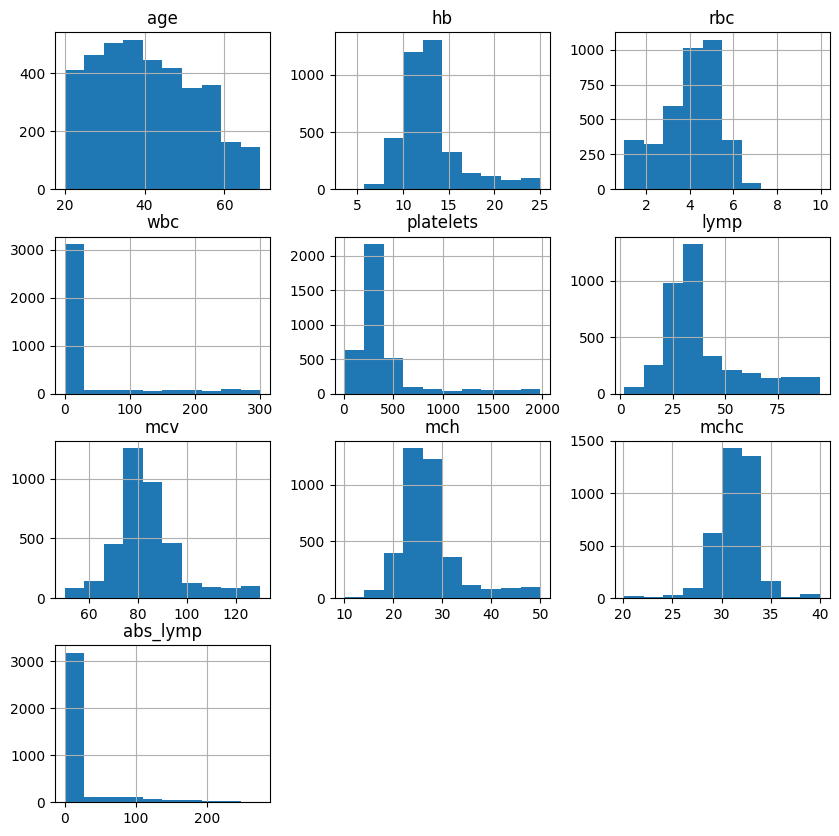

In [347]:
df.hist(figsize=(10,10))

In [348]:
bf_visualize_df=df.copy()

- There are a right skewed in wbc,platelets,abs_lymp and fix it using power transformer teqnique which find the best power to fix the data

In [349]:
pt = PowerTransformer(method='yeo-johnson')
cols_to_fix=['wbc','platelets','abs_lymp']
df[cols_to_fix] = pt.fit_transform(df[cols_to_fix])

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'hb'}>,
        <Axes: title={'center': 'rbc'}>],
       [<Axes: title={'center': 'wbc'}>,
        <Axes: title={'center': 'platelets'}>,
        <Axes: title={'center': 'lymp'}>],
       [<Axes: title={'center': 'mcv'}>, <Axes: title={'center': 'mch'}>,
        <Axes: title={'center': 'mchc'}>],
       [<Axes: title={'center': 'abs_lymp'}>, <Axes: >, <Axes: >]],
      dtype=object)

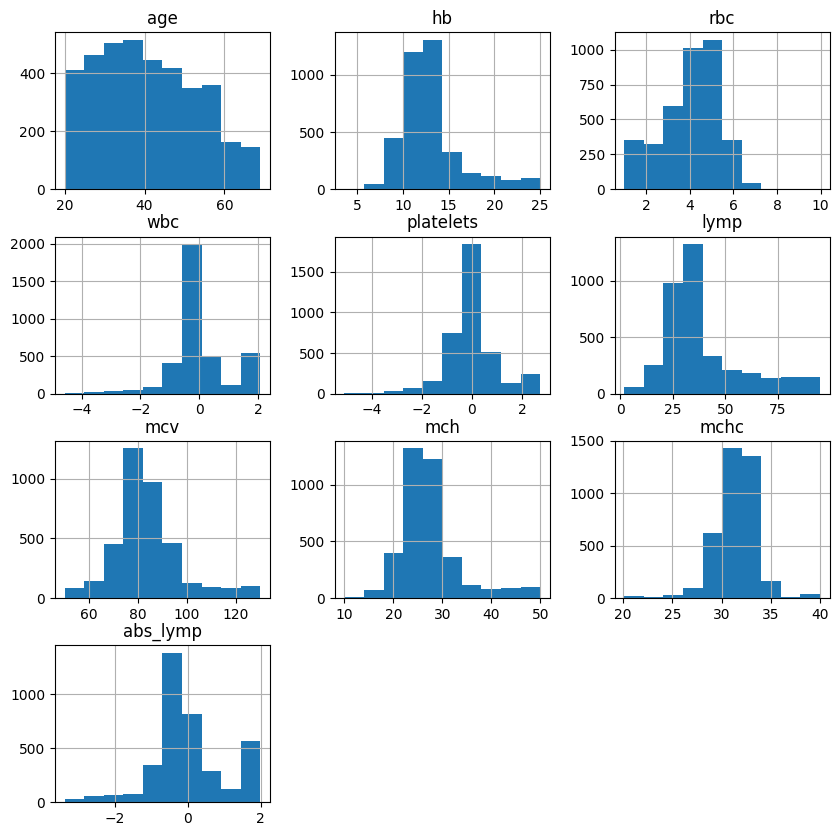

In [350]:
df.hist(figsize=(10,10))

In [351]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3768 entries, 0 to 3769
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 3768 non-null   int64  
 1   hb                  3768 non-null   float64
 2   rbc                 3768 non-null   float64
 3   wbc                 3768 non-null   float64
 4   platelets           3768 non-null   float64
 5   lymp                3768 non-null   float64
 6   mcv                 3768 non-null   float64
 7   mch                 3768 non-null   float64
 8   mchc                3768 non-null   float64
 9   abs_lymp            3768 non-null   float64
 10  pregnant_diagnoses  3768 non-null   object 
dtypes: float64(9), int64(1), object(1)
memory usage: 353.2+ KB


- fixed the skew

**Check Outliers**

In [352]:
numeric_cols=df.select_dtypes(exclude='object').columns
print(numeric_cols)

Index(['age', 'hb', 'rbc', 'wbc', 'platelets', 'lymp', 'mcv', 'mch', 'mchc',
       'abs_lymp'],
      dtype='object')


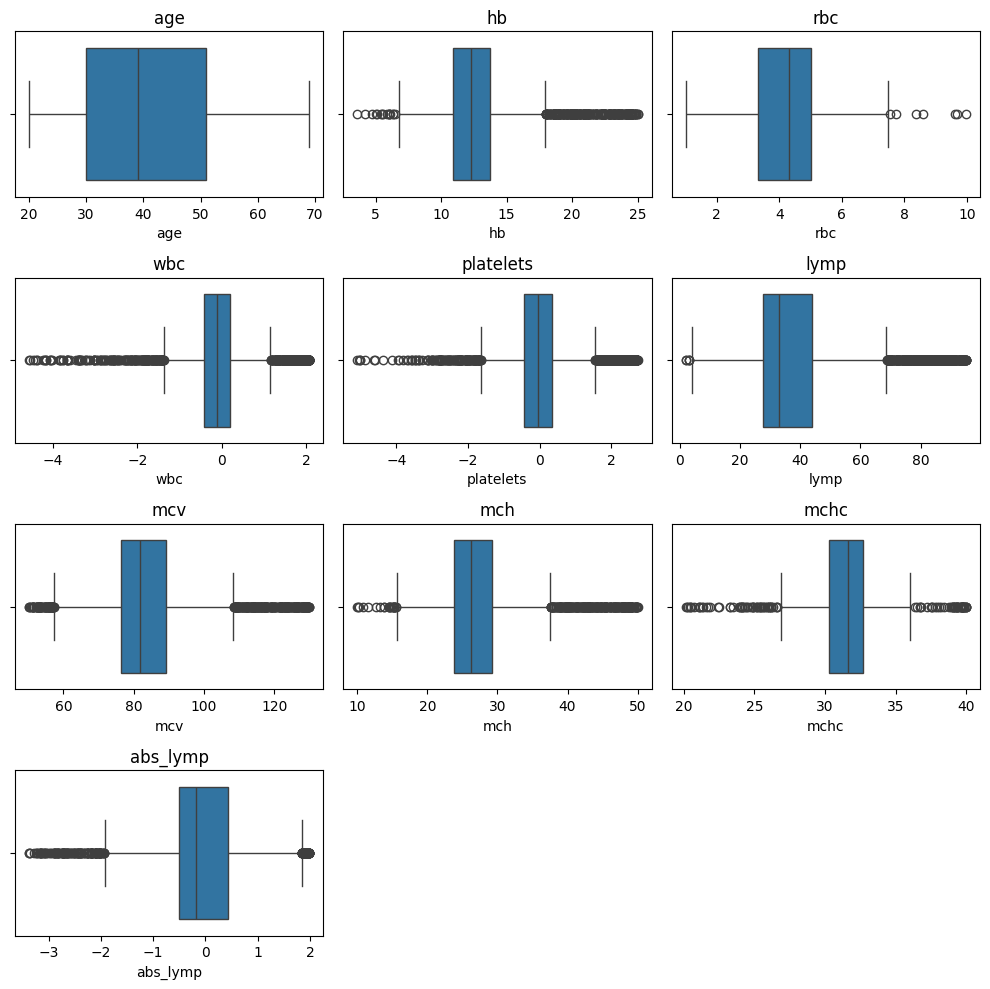

In [353]:
def boxplot_figure(cols:list,data_frame):
  # plt.figure(figsize=(15,15))
  fig,axes=plt.subplots(4,3,figsize=(10,10))
  axes=axes.flatten()
  for i,col in enumerate(cols):
    axes[i]=sns.boxplot(data=data_frame,x=col,ax=axes[i])
    axes[i].set_title(col)

  axes[10].axis('off')
  axes[11].axis('off')
  plt.tight_layout()
  plt.show()
boxplot_figure(numeric_cols,df)

In [354]:
df.describe()

,age,hb,rbc,wbc,platelets,lymp,mcv,mch,mchc,abs_lymp
count,3768.000000,3768.000000,3768.000000,3.768000e+03,3.768000e+03,3768.000000,3768.000000,3768.000000,3768.000000,3.768000e+03
mean,40.725849,12.905255,4.063607,-5.732617e-16,-4.224033e-16,39.022251,83.763663,27.335935,31.506294,-2.715450e-16
std,12.769690,3.274833,1.318929,1.000133e+00,1.000133e+00,18.897847,13.429888,6.049738,2.062398,1.000133e+00
min,20.000000,3.600000,1.000000,-4.572440e+00,-5.087558e+00,2.000000,50.152741,10.010000,20.115972,-3.380785e+00
25%,30.000000,10.900000,3.320000,-4.294753e-01,-4.428388e-01,27.600000,76.400000,23.800000,30.300000,-5.149256e-01
50%,39.000000,12.300000,4.320000,-1.234292e-01,-5.664186e-02,33.000000,81.800000,26.200000,31.600000,-1.815166e-01
75%,51.000000,13.700000,5.000000,2.011354e-01,3.542649e-01,44.000000,89.200000,29.300000,32.700000,4.283855e-01
max,69.000000,25.000000,9.970040,2.069368e+00,2.731724e+00,95.000000,130.000000,50.000000,39.984308,1.987552e+00


**Boxplot Conclusion**
  - Our data has womens with ages more than 55 and this may misleading our model.
  - wbc,platelets,abs_lymp the most columns with extreme values, and the negative values came from power transformation process.
  - other columns has a slightly extreme values than three columns previously mentioned.

**Let's see how much women higher than 50 in our data**

In [355]:
df[(df['age']>=50)|(df['age']<=18)].shape

(1017, 11)

In [356]:
aged_df=df[~(df['age']>=50)|(df['age']<=18)]

In [357]:
aged_df.shape

(2751, 11)

In [358]:
df.shape

(3768, 11)

In [359]:
aged_df.reset_index(drop=True,inplace=True)

In [360]:
aged_df.index

RangeIndex(start=0, stop=2751, step=1)

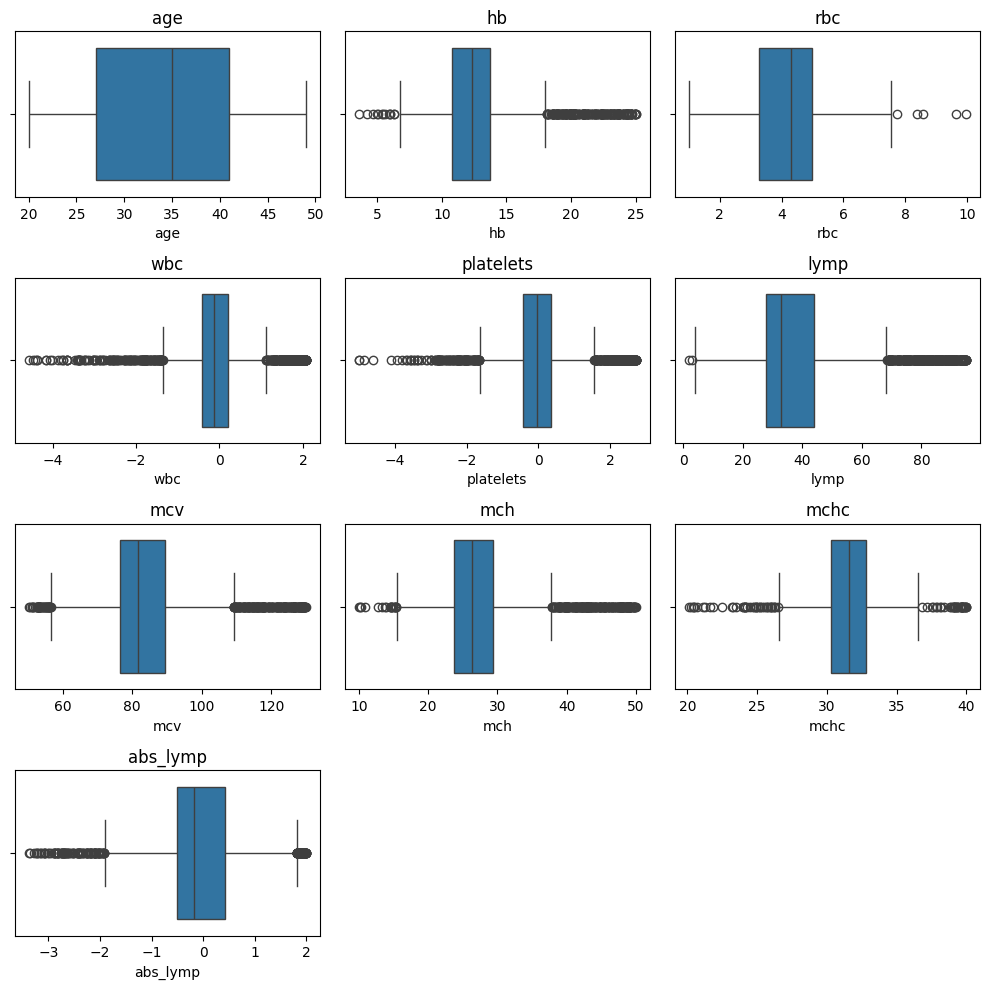

In [361]:
boxplot_figure(numeric_cols,aged_df)

**- For the outlier values we decided these values will be still in our data because it may be specilized for a critical or rare cases we need in our data**

**- That lead us to the need of choosen a model that handle outliers**

In [362]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(aged_df['pregnant_diagnoses'])
df_encoded=pd.DataFrame(y, columns=mlb.classes_)
df_encoded

,Anemia,Elevated Hemoglobin,Leukocytosis,Leukopenia,Lymphocytosis,Lymphopenia,Macrocytosis,Microcytosis,Thrombocytopenia,Thrombocytosis,normal
0,1,0,1,0,1,0,0,1,0,0,0
1,0,0,1,0,1,0,0,1,0,0,0
2,1,0,1,0,1,0,0,1,0,0,0
3,1,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2746,0,1,0,0,1,0,0,0,0,0,0
2747,0,0,0,0,0,0,0,1,0,0,0
2748,0,0,0,0,1,0,0,1,0,0,0
2749,0,1,0,0,1,0,0,0,0,1,0


In [363]:
aged_df.columns

Index(['age', 'hb', 'rbc', 'wbc', 'platelets', 'lymp', 'mcv', 'mch', 'mchc',
       'abs_lymp', 'pregnant_diagnoses'],
      dtype='object')

In [364]:
aged_df.drop(columns=['pregnant_diagnoses'],inplace=True)

/tmp/ipython-input-2886413928.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aged_df.drop(columns=['pregnant_diagnoses'],inplace=True)


In [365]:
aged_df.columns

Index(['age', 'hb', 'rbc', 'wbc', 'platelets', 'lymp', 'mcv', 'mch', 'mchc',
       'abs_lymp'],
      dtype='object')

**- know some information about our labels**

In [366]:
df_encoded['normal'].value_counts()[1]

np.int64(225)

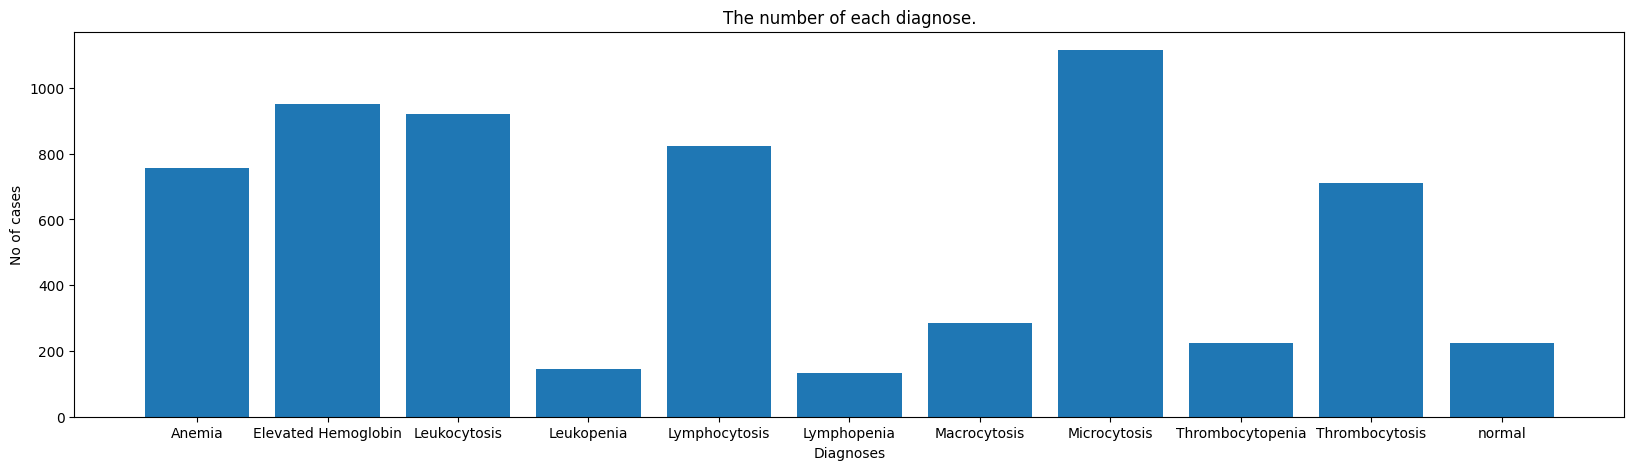

In [367]:
class_one_list=[]
encoded_columns=df_encoded.columns
for col in encoded_columns:
  class_one_list.append(df_encoded[col].value_counts()[1])

plt.figure(figsize=(20,5))
plt.bar(encoded_columns,class_one_list)
plt.title("The number of each diagnose.")
plt.xlabel("Diagnoses")
plt.ylabel("No of cases")
plt.show()

**- Correlation**

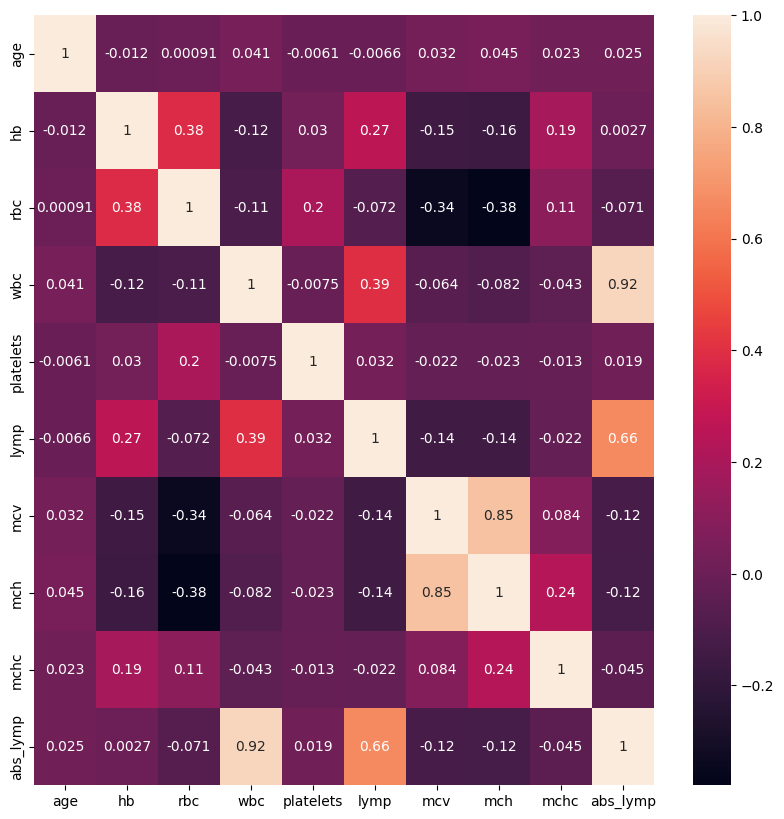

In [368]:
corr=aged_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)
plt.show()

- There is a high multicolinearity between wbc,abs_lymp and lymp
- abs_lymp and wbc are important which they determine some diagnoses so we can not drop them
- That lead us to drop lymp to reduce this colinearity
- also mch and mcv have a high correlation and mcv is an important factor in our diagnose
- That lead us to drop mch

In [369]:
before_corr_df=aged_df.copy()

In [370]:
corr_df=aged_df.drop(columns=['lymp','mch'])

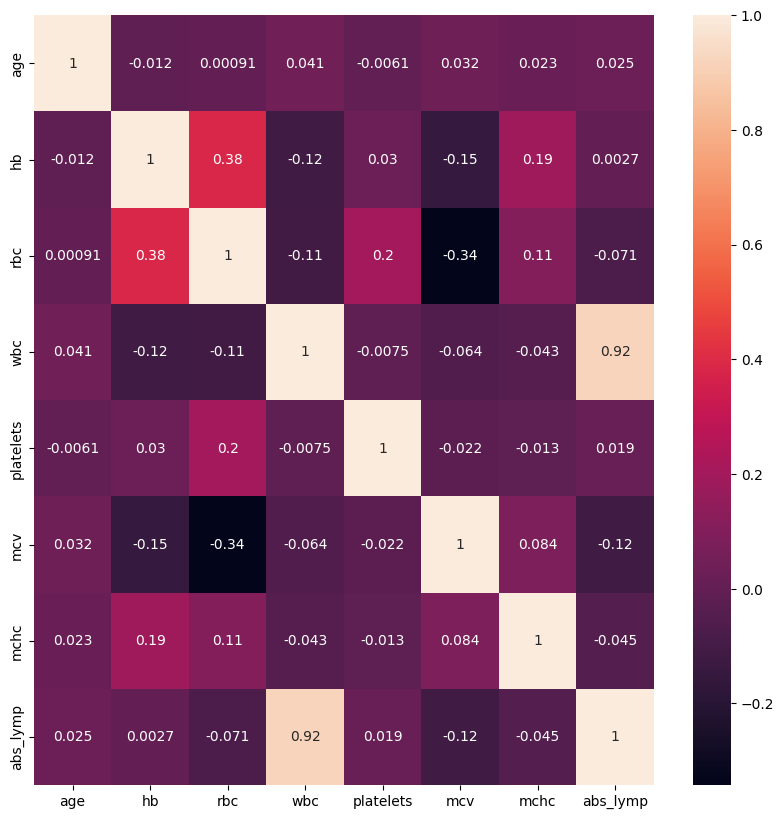

In [371]:
corr=corr_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)
plt.show()

-  no multi co linearity problem and the data are open to modeling

#Modeling

**- based on our exploring and all data we got we decided the best model to handel this data is decision tree model**

In [372]:
X_train, X_test, y_train, y_test = train_test_split(corr_df, y, test_size=0.2, random_state=42)

# Multi-label Random Forest model
base_rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
model = MultiOutputClassifier(base_rf)

print("Training multi-label Random Forest model...")
model.fit(X_train, y_train)
print("Training completed.\n")

Training multi-label Random Forest model...
Training completed.



In [373]:
# Evaluation
labels=df_encoded.columns
features=corr_df.columns
y_pred = model.predict(X_test)
print("=== Model Performance (Test Set) ===")
print(f"Subset Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Hamming Loss: {hamming_loss(y_test, y_pred):.4f}")
print(f"Micro F1: {f1_score(y_test, y_pred, average='micro'):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}\n")
# === FEATURE IMPORTANCE PER DIAGNOSIS (as requested) ===
print("=== Feature Contributions per Diagnosis ===")
importances = np.zeros((len(labels), len(features)))
for i, estimator in enumerate(model.estimators_):
    importances[i] = estimator.feature_importances_

# For each diagnosis, show top 3 features with their importance
for label_idx, label in enumerate(labels):
    top3_idx = np.argsort(importances[label_idx])[::-1][:3]
    contributions = []
    for idx in top3_idx:
        contributions.append(f"{features[idx]} ({importances[label_idx][idx]:.3f})")
    print(f"{label} -> {', '.join(contributions)}")

# === PREDICTION EXAMPLE ===
print("\n=== Sample Patient Prediction ===")
sample_idx = 0
sample_X = X_test[sample_idx:sample_idx+1]
sample_pred = model.predict(sample_X)[0]

predicted_diagnoses = [labels[i] for i in range(len(labels)) if sample_pred[i] == 1]

print("Predicted diagnoses for sample patient:", predicted_diagnoses)

=== Model Performance (Test Set) ===
Subset Accuracy: 0.9891
Hamming Loss: 0.0010
Micro F1: 0.9976
Macro F1: 0.9946

=== Feature Contributions per Diagnosis ===
Anemia -> hb (0.696), rbc (0.146), mcv (0.082)
Elevated Hemoglobin -> hb (0.771), rbc (0.116), mcv (0.029)
Leukocytosis -> wbc (0.701), abs_lymp (0.233), mcv (0.015)
Leukopenia -> wbc (0.556), abs_lymp (0.312), hb (0.073)
Lymphocytosis -> abs_lymp (0.659), wbc (0.257), hb (0.025)
Lymphopenia -> abs_lymp (0.562), wbc (0.323), hb (0.059)
Macrocytosis -> mcv (0.727), rbc (0.098), hb (0.093)
Microcytosis -> mcv (0.807), rbc (0.074), mchc (0.044)
Thrombocytopenia -> platelets (0.820), rbc (0.037), mcv (0.035)
Thrombocytosis -> platelets (0.847), rbc (0.032), wbc (0.029)
normal -> hb (0.258), mcv (0.161), platelets (0.154)

=== Sample Patient Prediction ===
Predicted diagnoses for sample patient: ['Elevated Hemoglobin', 'Leukopenia', 'Lymphopenia', 'Microcytosis', 'Thrombocytosis']


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


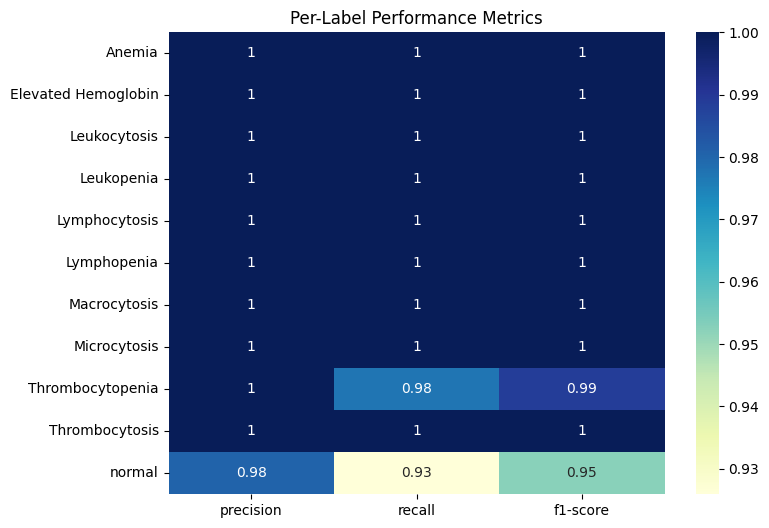

In [374]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, target_names=labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

metrics = df_report.loc[labels, ['precision','recall','f1-score']]

plt.figure(figsize=(8,6))
sns.heatmap(metrics, annot=True, cmap="YlGnBu")
plt.title("Per-Label Performance Metrics")
plt.show()

# Save the model

In [ ]:
import joblib
joblib.dump(model,'cbc_model.pkl')
joblib.dump(mlb,'mlb.pkl')
joblib.dump(pt,"power_transformer.pkl")

['power_transformer_3.pkl']

In [ ]:
corr_df.to_csv('final_cbc_df.csv')

In [ ]:
df_encoded.to_csv('final_label_df.csv')